# MENoBiS main use cases

This notebook demonstrates the two main applied workflows:

1. **Filter** observed node pairs against a null model.
2. **Sample** null networks and compare network magnitudes.

It also includes a short **partial-constraint** example and a fixed-strength ME
ensemble-equivalence check. All constraints are derived from generated
non-binary networks, so the fitted problems are feasible by construction.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from menobis.analysis import compute_all_stats, directed_strengths, weight_distribution
from menobis.filtering import filter_model
from menobis.models import Constraint, Ensemble, ModelFamily, fit_model, sample_model
from menobis.utilities.synthetic import (
    derive_synthetic_constraints,
    generate_pa_geographic_network,
    known_pairs_from_network,
)

plt.rcParams["figure.figsize"] = (7, 4)
plt.rcParams["axes.grid"] = True


## Generate an observed non-binary network

The synthetic fixture creates a directed sparse support with projected XY
coordinates. Occupations are non-negative integers. We use it as an observed
network, then derive constraints from it.


In [2]:
network = generate_pa_geographic_network(
    node_count=24,
    average_degree=5.0,
    events_per_edge=8.0,
    seed=2024,
    self_loops=False,
)
constraints = derive_synthetic_constraints(network)

pd.DataFrame(
    {
        "nodes": [len(network.x)],
        "observed_pairs": [network.edges.num_edges],
        "total_events": [network.edges.total_events],
        "total_cost": [constraints.total_cost],
    }
)


,nodes,observed_pairs,total_events,total_cost
0,24,120,960,360.86868


## Use case A: filter significant node pairs

We choose an ME strength-cost null because origin-destination trips are
**distinguishable events**. The fitted constraints are:

$$
s_i^{out}=\sum_j \mathbb{E}[t_{ij}],\qquad
s_j^{in}=\sum_i \mathbb{E}[t_{ij}],\qquad
C=\sum_{ij}\mathbb{E}[t_{ij}]d_{ij}.
$$

For the ME/Poisson family used here,

$$
\mathbb{E}[t_{ij}] = q_{ij} = x_i y_j\exp(-\gamma d_{ij}).
$$

Filtering then asks which observed occupations are too large under this null.


In [3]:
fit_cost = fit_model(
    family=ModelFamily.ME,
    constraint=Constraint.STRENGTH_COST,
    strength_out=constraints.strength_out,
    strength_in=constraints.strength_in,
    target_cost=constraints.total_cost,
    coord_x=network.x,
    coord_y=network.y,
    self_loops=False,
    tolerance=1e-6,
)

pd.DataFrame(
    {
        "converged": [fit_cost.converged],
        "status": [fit_cost.status],
        "iterations": [fit_cost.iterations],
        "gamma": [fit_cost.gamma],
    }
)


,converged,status,iterations,gamma
0,True,solved,26,2.913251


In [4]:
filtered = filter_model(
    network.edges,
    family=ModelFamily.ME,
    constraint=Constraint.STRENGTH_COST,
    fit=fit_cost,
    coord_x=network.x,
    coord_y=network.y,
    alpha=0.05,
    tail="upper",
)

pd.DataFrame(
    {
        "class": ["upper", "lower", "compatible", "absent_lower"],
        "pairs": [
            filtered.upper.edges.num_edges,
            filtered.lower.edges.num_edges,
            filtered.compatible.edges.num_edges,
            filtered.absent_lower.edges.num_edges,
        ],
    }
)


,class,pairs
0,upper,72
1,lower,0
2,compatible,48
3,absent_lower,0


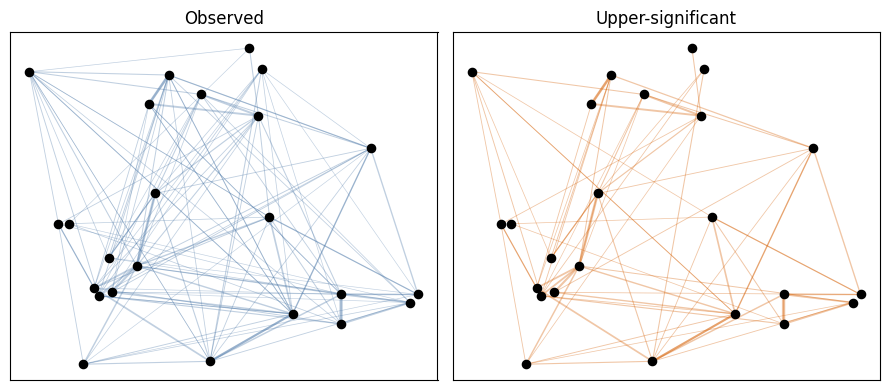

In [5]:
def plot_sparse_edges(ax, edges, title, *, color):
    ax.scatter(network.x, network.y, s=35, color="black", zorder=3)
    if edges.num_edges:
        max_w = float(edges.weight.max())
        for source, target, weight in zip(edges.source, edges.target, edges.weight, strict=True):
            width = 0.4 + 2.0 * float(weight) / max_w
            ax.plot(
                [network.x[int(source)], network.x[int(target)]],
                [network.y[int(source)], network.y[int(target)]],
                color=color,
                alpha=0.35,
                linewidth=width,
                zorder=1,
            )
    ax.set_title(title)
    ax.set_xticks([])
    ax.set_yticks([])

fig, axes = plt.subplots(1, 2, figsize=(9, 4))
plot_sparse_edges(axes[0], network.edges, "Observed", color="#4c78a8")
plot_sparse_edges(axes[1], filtered.upper.edges, "Upper-significant", color="#d55e00")
fig.tight_layout()


Text(0.5, 1.0, 'Observed occupation distribution')

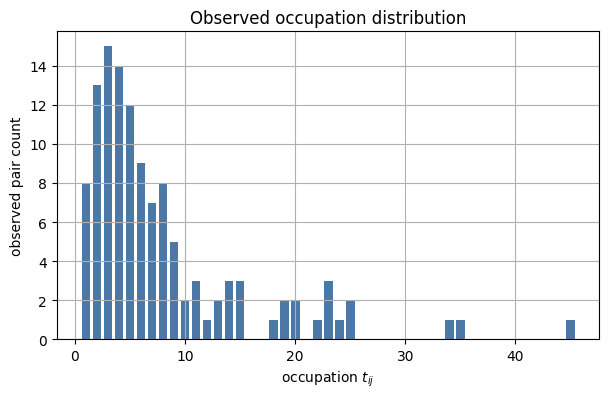

In [6]:
dist = weight_distribution(network.edges)
fig, ax = plt.subplots()
ax.bar(dist.weight, dist.count, color="#4c78a8")
ax.set_xlabel("occupation $t_{ij}$")
ax.set_ylabel("observed pair count")
ax.set_title("Observed occupation distribution")


## Use case B: sample an ensemble and compare magnitudes

Fit once, draw many null networks, compute the same magnitude on each sample,
and compare the observed value against the null distribution.


In [7]:
fit_strength = fit_model(
    family=ModelFamily.ME,
    constraint=Constraint.STRENGTH,
    strength_out=constraints.strength_out,
    strength_in=constraints.strength_in,
    self_loops=False,
)


def network_magnitudes(edges):
    stats = compute_all_stats(edges)
    return {
        "mean_y2_out": float(np.mean(np.nan_to_num(stats.y2_out))),
        "mean_snn_out": float(np.mean(np.nan_to_num(stats.s_nn_out))),
    }

observed_magnitudes = network_magnitudes(network.edges)
observed_magnitudes


{'mean_y2_out': 0.3606939487712492, 'mean_snn_out': 54.02085474859214}

In [8]:
sample_count = 1000
null_rows = []
for seed in range(sample_count):
    sample = sample_model(
        family=ModelFamily.ME,
        constraint=Constraint.STRENGTH,
        fit=fit_strength,
        seed=seed,
    )
    null_rows.append(network_magnitudes(sample))

null_df = pd.DataFrame(null_rows)
summary_df = null_df.agg(["mean", "std"])
summary_df.loc["p025"] = null_df.quantile(0.025)
summary_df.loc["p500"] = null_df.quantile(0.500)
summary_df.loc["p975"] = null_df.quantile(0.975)
summary_df.loc["observed"] = pd.Series(observed_magnitudes)
summary_df


,mean_y2_out,mean_snn_out
mean,0.125860,54.802128
std,0.014659,2.555530
p025,0.105164,49.805969
p500,0.122850,54.827211
p975,0.162318,59.786553
observed,0.360694,54.020855


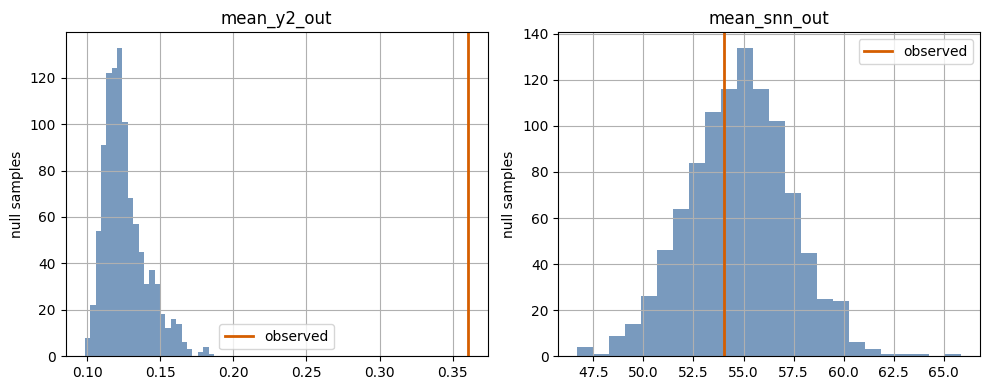

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, column in zip(axes, null_df.columns, strict=True):
    ax.hist(null_df[column], bins=24, color="#4c78a8", alpha=0.75)
    ax.axvline(observed_magnitudes[column], color="#d55e00", linewidth=2, label="observed")
    ax.set_title(column)
    ax.set_ylabel("null samples")
    ax.legend()
fig.tight_layout()


## Partial constraints: freeze known pairs

Partial fitting is useful when some node-pair occupations are trusted and should
not be randomized. MENoBiS subtracts those known occupations from the requested
constraints and fits the free support.


In [10]:
known_source, known_target, known_rate = known_pairs_from_network(network, fraction=0.10)
partial_fit = fit_model(
    family=ModelFamily.ME,
    constraint=Constraint.STRENGTH_COST,
    strength_out=constraints.strength_out,
    strength_in=constraints.strength_in,
    target_cost=constraints.total_cost,
    coord_x=network.x,
    coord_y=network.y,
    known_source=known_source,
    known_target=known_target,
    known_rate=known_rate,
    self_loops=False,
    tolerance=1e-6,
)

pd.DataFrame(
    {
        "known_pairs": [len(known_source)],
        "combined_rate_rows": [len(partial_fit.rate)],
        "converged": [partial_fit.converged],
        "status": [partial_fit.status],
    }
)


,known_pairs,combined_rate_rows,converged,status
0,12,552,True,solved


## ME fixed-strength ensemble equivalence

This is the only MENoBiS constraint for which we know how to sample the three ME
ensembles in a fully unbiased way: grand canonical Poisson, canonical
fixed-total multinomial, and microcanonical fixed-strength stub matching. We use
a separate self-loop-enabled fixture, then compare Monte Carlo estimates of the
same pair expectation as the number of sampling iterations grows.


In [11]:
equiv_network = generate_pa_geographic_network(
    node_count=16,
    average_degree=5.0,
    events_per_edge=6.0,
    seed=99,
    self_loops=True,
)
equiv_constraints = derive_synthetic_constraints(equiv_network)
equiv_strength = fit_model(
    family=ModelFamily.ME,
    constraint=Constraint.STRENGTH,
    strength_out=equiv_constraints.strength_out,
    strength_in=equiv_constraints.strength_in,
    self_loops=True,
)

# Track the strongest observed pair in the fixture.
focal_index = int(np.argmax(equiv_network.edges.weight))
focal_source = int(equiv_network.edges.source[focal_index])
focal_target = int(equiv_network.edges.target[focal_index])
analytic_mean = (
    equiv_constraints.strength_out[focal_source]
    * equiv_constraints.strength_in[focal_target]
    / equiv_constraints.total_events
)


def pair_value(edges, source, target):
    mask = (edges.source == source) & (edges.target == target)
    return int(edges.weight[mask].sum()) if np.any(mask) else 0

ensemble_values = {"grand": [], "canonical": [], "microcanonical": []}
mc_iterations = 300
for seed in range(mc_iterations):
    ensemble_values["grand"].append(
        pair_value(
            sample_model(
                family=ModelFamily.ME,
                constraint=Constraint.STRENGTH,
                fit=equiv_strength,
                seed=seed,
            ),
            focal_source,
            focal_target,
        )
    )
    ensemble_values["canonical"].append(
        pair_value(
            sample_model(
                ensemble=Ensemble.CANONICAL,
                family=ModelFamily.ME,
                constraint=Constraint.STRENGTH,
                fit=equiv_strength,
                total_events=equiv_constraints.total_events,
                seed=seed,
            ),
            focal_source,
            focal_target,
        )
    )
    ensemble_values["microcanonical"].append(
        pair_value(
            sample_model(
                ensemble=Ensemble.MICROCANONICAL,
                family=ModelFamily.ME,
                constraint=Constraint.STRENGTH,
                strength_out=equiv_constraints.strength_out.astype("uint64"),
                strength_in=equiv_constraints.strength_in.astype("uint64"),
                seed=seed,
            ),
            focal_source,
            focal_target,
        )
    )

pd.DataFrame(
    {
        "ensemble": list(ensemble_values),
        "sample_mean_tij": [np.mean(v) for v in ensemble_values.values()],
        "sample_std_tij": [np.std(v) for v in ensemble_values.values()],
        "analytic_E_tij": [analytic_mean] * 3,
    }
)


,ensemble,sample_mean_tij,sample_std_tij,analytic_E_tij
0,grand,22.143333,5.056625,22.633333
1,canonical,22.400000,4.837355,22.633333
2,microcanonical,22.813333,3.660395,22.633333


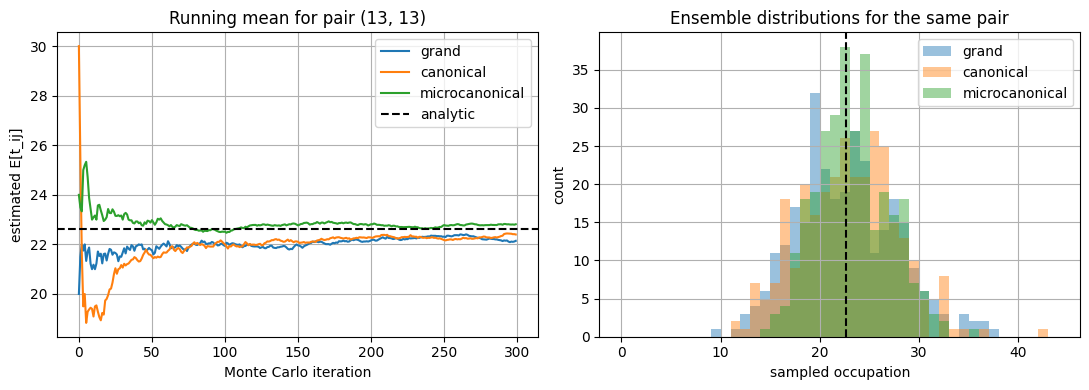

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for name, values in ensemble_values.items():
    values = np.asarray(values, dtype=float)
    running = np.cumsum(values) / np.arange(1, len(values) + 1)
    axes[0].plot(running, label=name)
    axes[1].hist(values, bins=range(0, int(values.max()) + 3), alpha=0.45, label=name)
axes[0].axhline(analytic_mean, color="black", linestyle="--", label="analytic")
axes[0].set_title(f"Running mean for pair ({focal_source}, {focal_target})")
axes[0].set_xlabel("Monte Carlo iteration")
axes[0].set_ylabel("estimated E[t_ij]")
axes[1].axvline(analytic_mean, color="black", linestyle="--")
axes[1].set_title("Ensemble distributions for the same pair")
axes[1].set_xlabel("sampled occupation")
axes[1].set_ylabel("count")
for ax in axes:
    ax.legend()
fig.tight_layout()


## Interpretation

- Filtering reports node-pair surprises relative to the selected constraints.
- Ensemble sampling reports whether network-level magnitudes are typical under
  the same constraints.
- Partial constraints freeze trusted pairs and fit the remaining support.
- Fixed-strength ME ensemble equivalence is a diagnostic example, not a reason
  to use coupled ensembles by default. Grand canonical remains the practical
  default for large independent-pair workflows.
